### Objective: Cross-reference the specral bands of landsat and sentinel ***over waterbodies***


#### Load packages

In [95]:
import datacube
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from deafrica_tools.plotting import rgb
from deafrica_tools.app import geomedian

#### Connect to the datacube

In [96]:
dc = datacube.Datacube(app='HarmonisingLandsatandSentinel') #testing what difference the 'app' value makes...

### List products

In [213]:
# List GeoMAD products available in DE Africa
dc_products = dc.list_products()
display_columns = ['name', 'description']
dc_products[dc_products.name.str.contains(
    's2').fillna(
        False)][display_columns].set_index('name')

,description
name,
gm_s2_annual,Surface Reflectance Annual Geometric Median an...
gm_s2_annual_lowres,"Annual Geometric Median, Sentinel-2 - Low Reso..."
gm_s2_rolling,Surface Reflectance 3 Monthly Rolling Geometri...
gm_s2_semiannual,Surface Reflectance Semiannual Geometric Media...
gm_s2_semiannual_lowres,Surface Reflectance Semiannual Geometric Media...
pc_s2_annual,"Surface Reflectance Annual Clear Pixel Count, ..."
s2_l2a,"Sentinel-2a and Sentinel-2b imagery, processed..."


### List measurements using datacube's `list_measurements` functionality.
 'measurements' seems to omit the most fundamental description, i.e. the central wavelength...
 
 Note that the geomedians don't include all the bands, which is odd.

In [214]:
product_name = 'gm_s2_annual'
product_name = 'wofs_ls_summary_alltime'
product_name = 'ls8_st'
product_name = 'ls8_sr'
product_name = "gm_ls8_ls9_annual"
product_name = "s2_l2a"

dc_measurements = dc.list_measurements()
dc_measurements.loc[product_name].drop('flags_definition', axis=1)

,name,dtype,units,nodata,aliases
measurement,,,,,
B01,B01,uint16,1,0.0,"[band_01, coastal_aerosol]"
B02,B02,uint16,1,0.0,"[band_02, blue]"
B03,B03,uint16,1,0.0,"[band_03, green]"
B04,B04,uint16,1,0.0,"[band_04, red]"
B05,B05,uint16,1,0.0,"[band_05, red_edge_1]"
B06,B06,uint16,1,0.0,"[band_06, red_edge_2]"
B07,B07,uint16,1,0.0,"[band_07, red_edge_3]"
B08,B08,uint16,1,0.0,"[band_08, nir, nir_1]"
B8A,B8A,uint16,1,0.0,"[band_8a, nir_narrow, nir_2]"


Let's also inpsect the measurements of the Landsat 8-9 GeoMAD, `gm_ls8_ls9_annual`

### Set the spatial and temporal domains and highest approriate grid resolution

In [99]:
#Set the space-time domain(s) of interest using a python dictionary object:

#few_pixels is useful for debugging and exploration
few_pixels = {"x": (33.1600,33.16005),
         "y": (-2.1200, -2.1424),
         "time": ("2017","2022")}

small_area = {"x": (33.1655,33.1864),
         "y": (-2.1444,-2.1532),
         "time": ("2017","2022")}

cameroon_waterbody = {"y": (6.20,6.30),
                      "x": (11.25, 11.35),
                      "time": ("2017","2021")}

Lake_Victoria = {"x": (33.100,33.300),
         "y": (-2.0800,-2.1500),
         "time": ("2017","2022")}

Lake_Mweru = {"x": (28.200,29.300),
         "y": (-8.500,-9.500),
         "time": ("2017","2022")}

Senegal_StLouis = {"x": (-15.74,-15.84),
         "y": (16.3,16.3900),
         "time": ("2018","2022")}

Ghana_AwunaBeach = {"x": (-1.608,-1.635),
         "y": (5.01, 5.05),
         "time": ('2018','2024')}



#Need to set a geographic sampling frame based on the extent, with min 10m and max 1000m


#only the last one will matter here, of course
#spacetime_domain = eye_of_africa
#spacetime_domain = cameroon_waterbody
#spacetime_domain = few_pixels
#spacetime_domain = small_area
#spacetime_domain = Lake_Victoria
spacetime_domain = Lake_Mweru
#spacetime_domain = Senegal_StLouis
spacetime_domain = Ghana_AwunaBeach



#establish a reasonable grid resolution between min and max based on the AOI
cell_min = 10
cell_max = 500
x0 = spacetime_domain["x"][0]
x1 = spacetime_domain["x"][1]
y0 = spacetime_domain["y"][0]
y1 = spacetime_domain["y"][1]
dxm = ((x1-x0) * 100000) * np.cos(y0 * np.pi/180.0) #metres approx allowing for lattitudinal compression of dx
dym = ((y1-y0) * 100000) #metres approx
dAm = dxm * dym        #sqare metres total extent
max_cells = 1000000  #grid cells covering the extent, about 100km2 at 10m resolution
cell_m2 = dAm / max_cells
cell_dxm = abs(cell_m2)**0.5


if cell_dxm < cell_min :
    cell_dxm = cell_min
else :
    if cell_dxm > cell_max :
        cell_dxm = cell_max
cell_dxm = int(cell_dxm / 10) * 10
grid_resolution = (-cell_dxm,cell_dxm) 
print("grid resolution will be:", grid_resolution)

aspect_ratio = np.abs(dym/dxm)


grid resolution will be: (-10, 10)


### Set the measurements to be used (which 'bands')

In [100]:
#set the measurement (variables) domain using a python dictionary object:


mmts_wofs = {"measurements":("frequency","count_clear","count_wet")}
bands_sentinel = {"measurements":("B02","B03","B04","B12","B05","B06","B07","smad","emad","bcmad","count")}
bands_landsat  = {"measurements":("SR_B2","SR_B3","SR_B4","SR_B5","SR_B6","SR_B7","smad","emad","bcmad","count")}

measurement_domain_sentinel = bands_sentinel
measurement_domain_landsat = bands_landsat


### Load the data from the datacube for the **space**, **time** and **measurement** domains of interest

Landsat 8, and 8_9 are identical and can bee loaded in a single step:

In [101]:
# load data 
# for the space-time-measurement domains specified earlier
#    for null measurement_domain need to comment it out because an empty list does not work
#wofs     = "wofs_ls_summary_alltime"


landsat89  = dc.load(product=("gm_ls8_annual","gm_ls8_ls9_annual"),
             **spacetime_domain,
             **measurement_domain_landsat,
             resolution=grid_resolution,
             align=(0,0),
             resampling="bilinear"
             )
sentinel = dc.load(product=("gm_s2_annual"),
             **spacetime_domain,
             **measurement_domain_sentinel,
             resolution=grid_resolution,
             align=(0,0),
             resampling="bilinear"

            )

wofs = dc.load(
                product="wofs_ls_summary_alltime",
                **mmts_wofs,
                resampling='bilinear',
                like=landsat89.geobox
                ).squeeze()

#based on Chad's code, add this: .filtered.squeeze()  



print(sentinel,landsat89, wofs)

<xarray.Dataset>
Dimensions:      (time: 5, y: 509, x: 261)
Coordinates:
  * time         (time) datetime64[ns] 2018-07-02T11:59:59.999999 ... 2022-07...
  * y            (y) float64 6.434e+05 6.434e+05 ... 6.384e+05 6.384e+05
  * x            (x) float64 -1.578e+05 -1.577e+05 ... -1.552e+05 -1.552e+05
    spatial_ref  int32 6933
Data variables:
    B02          (time, y, x) uint16 622 609 598 640 664 ... 1149 1149 1144 1126
    B03          (time, y, x) uint16 880 841 832 892 925 ... 1615 1607 1594 1560
    B04          (time, y, x) uint16 653 625 615 677 743 ... 1344 1336 1325 1276
    B12          (time, y, x) uint16 1093 1061 1108 1135 ... 348 347 339 342
    B05          (time, y, x) uint16 1218 1148 1166 1186 ... 1237 1242 1227 1193
    B06          (time, y, x) uint16 2841 2831 2924 2977 ... 801 807 796 781
    B07          (time, y, x) uint16 3439 3474 3591 3660 ... 827 832 818 804
    smad         (time, y, x) float32 0.002356 0.002569 ... 0.01989 0.02088
    emad         (tim

### View the geomedian for the area
sentinel.time()

### At the expense of the MADs (for now at least), we can merge the data to a single dataset, Annual Surface Reflectance, or ASR:
Also check the response of longer wavelengths over water with a view to Rayleigh correction. 

### Filtering the pixels over water reveals the mean values of the IR bands, which can be used to shift the scale - after conversion to reflectance.

In [202]:
ASR = xr.merge([landsat89,sentinel],compat='override')

In [166]:
#print(ASR.B02)

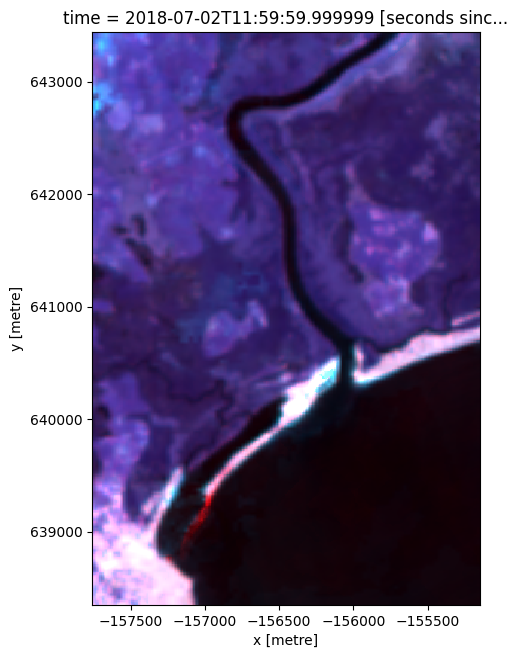

In [209]:
#some elegant code from the xarray tutorial: (still returns an error somewhere)
ASR[['B12', 'SR_B7', 'SR_B6']].isel(time=0).to_array().plot.imshow(robust=True, figsize=(5, 5*aspect_ratio));


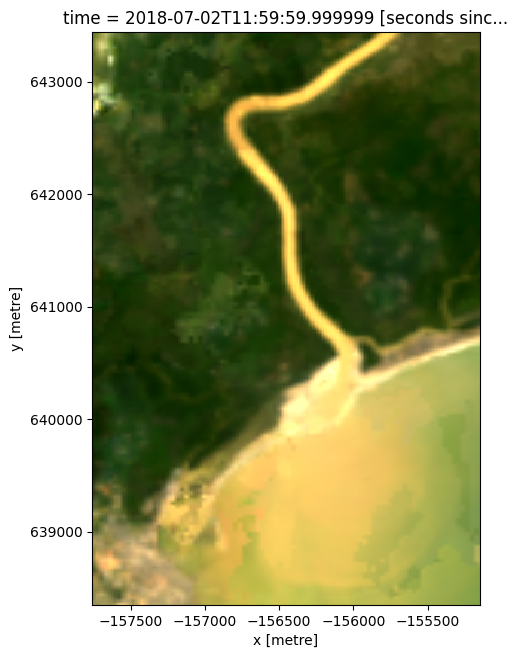

In [168]:
#some elegant code from the xarray tutorial: (still returns an error somewhere)
ASR[['SR_B4', 'SR_B3', 'SR_B2']].isel(time=0).to_array().plot.imshow(robust=True, figsize=(5, 5*aspect_ratio))

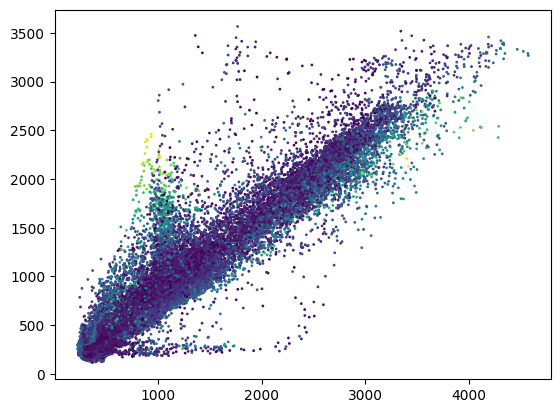

In [198]:
#data2plot = data2plot.reset_coords(names='time', drop=True) #removes time as a coordinate
data2plot = ASR.isel(time=0)
data2plot['delta'] = (data2plot['B04'] - 1.0 * data2plot['SR_B4'])
data2plot['delta'] = np.abs(data2plot['delta'])
data2plot['size'] = 1
plt.scatter('B12','SR_B7',c='delta',s='size',data=data2plot)


Now apply a filter using the WOFS all time summary; extract where there is 90% chance that there is water, i.e., where the frequency is greater than 0.9. 

In [170]:
#drop time from wofs
wofs = wofs.reset_coords(names='time',drop=True)

ValueError: These variables cannot be found in this dataset: ['time']

In [154]:
water_frequency_threshold = 0.5
wofs['mask'] = 1. 
wofs['mask'] = wofs['mask'].where(wofs['frequency'] > water_frequency_threshold)
mask_cells = wofs['mask'].count(dim = ('x','y'))


In [182]:
print(wofs['mask'].count())

<xarray.DataArray 'mask' ()>
array(40616)
Coordinates:
    spatial_ref  int32 6933


In [156]:
print(abs(grid_resolution[0] * grid_resolution[1]) / 1000000)

0.0001


In [161]:
print('Mask area of water within the study area is :', mask_cells.sum().values * abs(grid_resolution[0]*grid_resolution[1]) / 1000000,' km2. '
     ,'Based on a frequency threshold of: ',water_frequency_threshold)

Mask area of water within the study area is : 4.0616  km2.  Based on a frequency threshold of:  0.5


### Trim the data to the water areas:

In [222]:
ASR = ASR.where(wofs['mask']==1)

/usr/local/lib/python3.10/dist-packages/matplotlib/cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


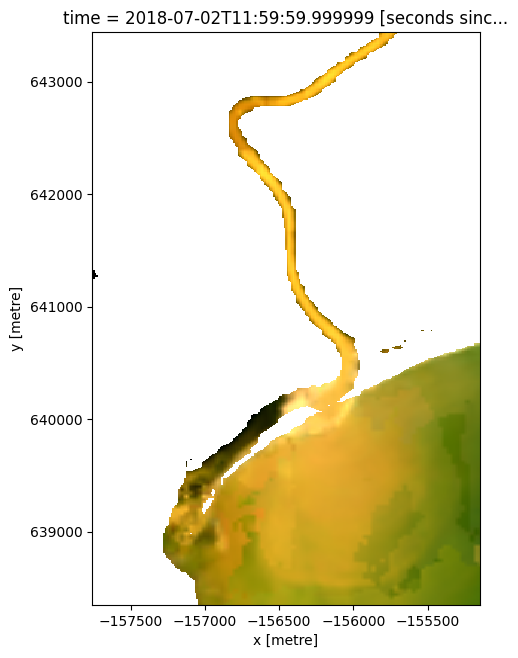

In [200]:
#some elegant code from the xarray tutorial: (still returns an error somewhere)
ASR[['SR_B4', 'SR_B3', 'SR_B2']].isel(time=0).to_array().plot.imshow(robust=True, figsize=(5, 5*aspect_ratio))

/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:6763: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:6764: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


(array([[  0.,   9.,   0., ...,   0.,   0.,   0.],
        [  3.,   5.,   0., ...,   0.,   0.,   0.],
        [  4.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [233.,   0.,   0., ...,   0.,   0.,   0.],
        [233.,   0.,   0., ...,   0.,   0.,   0.],
        [233.,   0.,   0., ...,   0.,   0.,   0.]]),
 array([ 157.        ,  549.09997559,  941.20001221, 1333.30004883,
        1725.40002441, 2117.5       , 2509.60009766, 2901.69995117,
        3293.80004883, 3685.89990234, 4078.        ]),
 <a list of 261 BarContainer objects>)

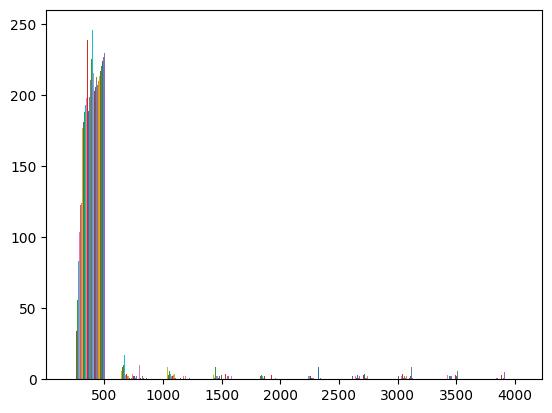

In [227]:
#data2plot = data2plot.reset_coords(names='time', drop=True) #removes time as a coordinate
data2plot = ASR.isel(time=1)
data2plot['delta'] = (data2plot['B04'] - 1.0 * data2plot['SR_B4'])
data2plot['delta'] = np.abs(data2plot['delta'])
data2plot['size'] = 1
#plt.scatter('B12','SR_B7',c='delta',s='size',data=data2plot)
plt.hist('B12', data=data2plot)

In [194]:
ASR

<xarray.Dataset>
Dimensions:      (time: 5, y: 509, x: 261)
Coordinates:
  * time         (time) datetime64[ns] 2018-07-02T11:59:59.999999 ... 2022-07...
  * y            (y) float64 6.434e+05 6.434e+05 ... 6.384e+05 6.384e+05
  * x            (x) float64 -1.578e+05 -1.577e+05 ... -1.552e+05 -1.552e+05
    spatial_ref  int32 6933
Data variables: (12/17)
    SR_B2        (time, y, x) float32 nan nan nan nan ... 911.0 890.0 870.0
    SR_B3        (time, y, x) float32 nan nan nan ... 1.669e+03 1.638e+03
    SR_B4        (time, y, x) float32 nan nan nan ... 1.783e+03 1.737e+03
    SR_B5        (time, y, x) float32 nan nan nan nan ... 958.0 924.0 891.0
    SR_B6        (time, y, x) float32 nan nan nan nan ... 280.0 275.0 269.0
    SR_B7        (time, y, x) float32 nan nan nan nan ... 203.0 199.0 194.0
    ...           ...
    B03          (time, y, x) float32 nan nan nan ... 1.594e+03 1.56e+03
    B04          (time, y, x) float32 nan nan nan ... 1.325e+03 1.276e+03
    B12          (time, y, x) float32 nan nan nan nan ... 347.0 339.0 342.0
    B05          (time, y, x) float32 nan nan nan ... 1.227e+03 1.193e+03
    B06          (time, y, x) float32 nan nan nan nan ... 807.0 796.0 781.0
    B07          (time, y, x) float32 nan nan nan nan ... 832.0 818.0 804.0
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

In [94]:
#Model_B2 = np.polyfit(ASR.B04.isel(time=0),ASR.SR_B4.isel(time=0),1)

TypeError: expected 1D vector for x

#### Re-scale the geomedian variations for visualisation (ONLY!).
The way this is done below - reading back to the same dataset - is risky since if the cell is run again the data values will stretch again. Better to do it dynamically in the rgb function or produce a temporary dataset

In [12]:
smad_scaling = [np.log(ds.smad.quantile(0.02).values), np.log(ds.smad.quantile(0.98).values)]
emad_scaling = [np.log(ds.emad.quantile(0.02).values), np.log(ds.emad.quantile(0.98).values)]
bcmad_scaling = [np.log(ds.bcmad.quantile(0.02).values), np.log(ds.bcmad.quantile(0.98).values)]

NameError: name 'ds' is not defined

In [13]:
#this code is not a good idea but keeping it for reference 
#ds['smad'] = (np.log(ds.smad)-smad_scaling[0])/(smad_scaling[1]- smad_scaling[0])
#ds['emad'] = (np.log(ds.emad)-emad_scaling[0])/(emad_scaling[1]- emad_scaling[0])
#ds['bcmad'] = (np.log(ds.bcmad)-bcmad_scaling[0])/(bcmad_scaling[1]- bcmad_scaling[0])


In [14]:
temp_smad = (np.log(ds.smad)-smad_scaling[0])/(smad_scaling[1]- smad_scaling[0])
temp_emad = (np.log(ds.emad)-emad_scaling[0])/(emad_scaling[1]- emad_scaling[0])
temp_bcmad = (np.log(ds.bcmad)-bcmad_scaling[0])/(bcmad_scaling[1]- bcmad_scaling[0])
temp = xr.merge([temp_smad,temp_emad,temp_bcmad])


NameError: name 'ds' is not defined

In [15]:
rgb(temp,bands=["smad","emad","bcmad"],col='time',robust=True)

NameError: name 'temp' is not defined

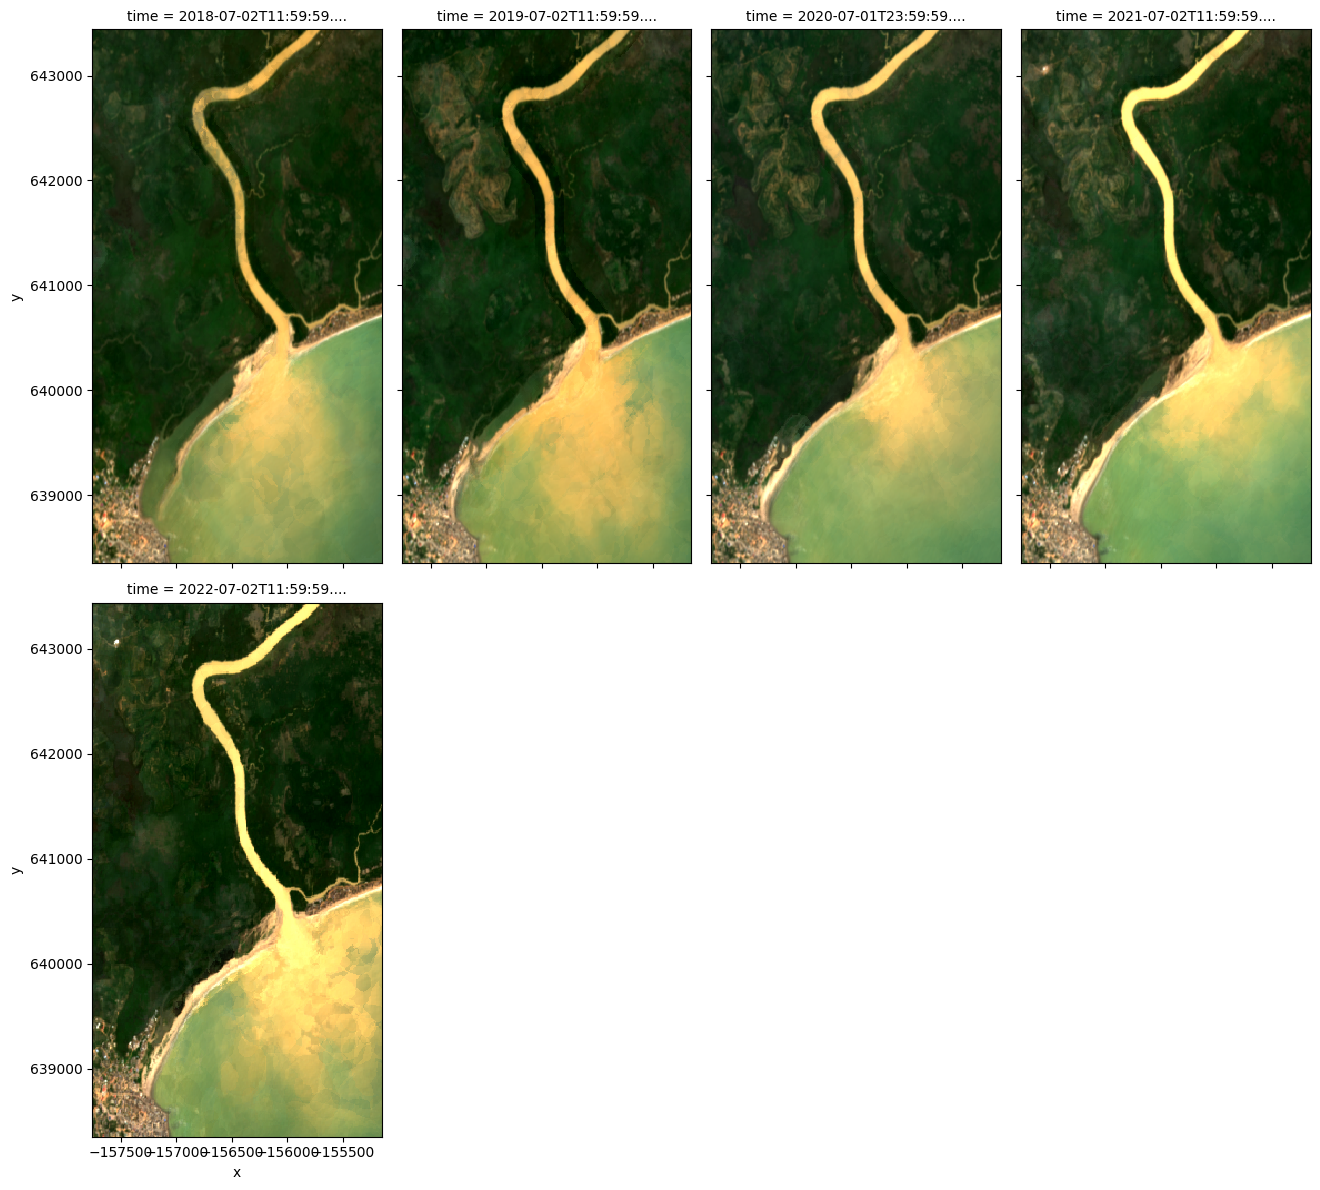

In [16]:
#plot the datasets, or scaled mads
rgb (ASR,bands=["B04","B03","B02"],col="time")
#rgb (temp,bands=["smad","emad","bcmad"],col="time")

In [17]:
#rgb(ds, index=[0,1]) #note that "rgb" function is default wired to look for data fields called red greeen blue ....
#print(ds.isel(time=1))
print(ds)

NameError: name 'ds' is not defined

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:** 

In [17]:
print(datacube.__version__)

1.8.15


**Last Tested:**

In [18]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2023-08-11'